In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 8** - Maximising an 8D Black-Box Function

- Optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output but the internal mechanics are unknown. 
    - Because the function is high-dimensional and likely complex, global optimisation is hard, identifying strong local maxima is the practical strategy.

- For example, imagine tuning an ML model with eight hyperparameters: learning rate, batch size, number of layers, dropout rate, regularisation strength, activation function (encoded), optimiser type (encoded) and initial weight range.

**Input** - 8D array  
**Output** - 1D array  
**Optimisation Goal** - Maximise  
**All-time best:** 9.951 at [0.111, 0.167, 0.129, 0.229, 0.996, 0.475, 0.302, 0.476] (Week 3)

In [2]:
# Load current cumulative dataset (original + prior weekly updates) for Function 8
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_outputs.npy')

# New data from Week 11 (Function 8)
X_w11_new_point = np.array([0.044183, 0.428925, 0.125607, 0.292137, 0.508113, 0.408821, 0.089857, 0.038714], dtype=np.float64)
Y_w11_new_point = np.array([9.7890291685779], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w11_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w11_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_outputs.npy', Y_updated)

# Show updated arrays
print("Updated Inputs (X) - Function 8: ", X_unique)
print("Updated Outputs (Y) - Function 8: ", Y_updated)

Updated Inputs (X) - Function 8:  [[0.007838   0.337307   0.164679   0.407388   0.632409   0.551169
  0.306982   0.5023    ]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.014565   0.233424   0.15641    0.215734   0.993571   0.163832
  0.082661   0.95629   ]
 [0.02894663 0.02827906 0.48137155 0.6131746  0.67266045 0.02211341
  0.6014833  0.52488505]
 [0.029788   0.370437   0.009211   0.56322    0.914458   0.813905
  0.149129   0.554138  ]
 [0.0417     0.167136   0.185989   0.004377   0.961301   0.357272
  0.961301   0.357272  ]
 [0.044183   0.428925   0.125607   0.292137   0.508113   0.408821
  0.089857   0.038714  ]
 [0.04432925 0.01358149 0.25819824 0.57764416 0.05127992 0.15856307
  0.59103012 0.07795293]
 [0.05644741 0.06595555 0.02292868 0.03878647 0.40393544 0.80105533
  0.48830701 0.89308498]
 [0.097603   0.135405   0.156089   0.022873   0.887585   0.187209
  0.032006   0.53162   ]
 [0.110613   0.166799   0.129222   0.228937   0.

## **Output Analysis**

- This week I got a regression to 9.789 which was smaller from last weeks 9.890.

    - A regression after three weeks of improvement. 
        - w11 queried [0.044, 0.429, 0.126, 0.292, 0.508, 0.409, 0.090, 0.039] 
            - Critically, x5=0.508 is well below the confirmed optimal x5≈0.996. 

    - The blended-coordinate strategy used in w11 (taking w10 dims but boosting x5 to 0.990) did not prevent x5 from collapsing in the actual query. 
        - This is the same x5 problem seen repeatedly.

- **Real-World Implication:** In an 8D stochastic system, a regression from 9.890 to 9.789 is meaningful but not catastrophic
    - We are still on the high-performance plateau. 
    
    - However, x5 drifting to 0.508 is a clear systematic failure. 
        - The blended-coordinate approach is not reliably pinning x5 to its optimal value.

- **Model Clues:** w12 must implement a **hard floor constraint on x5 ≥ 0.95**, mirroring the successful floor constraints used for F6. 
    - The pattern is identical: x5 consistently collapses when left to the acquisition function, and consistently produces good results when it is high.

## **Bayesian Optimisation** - Gaussian Process Regressor

- **Model:** Matern (nu=2.5) + WhiteKernel + Yeo-Johnson, n_restarts=25. Unchanged.

- **On Neural Networks:** Function 8 is the highest-dimensional function (8D) and the most stochastic. Neural networks struggle in high dimensions with sparse data, and stochastic outputs further confuse gradient-based learning.

In [3]:
Y_transformed = power_transform(Y_updated.reshape(-1, 1), method='yeo-johnson').ravel()

print('Original Y:', Y_updated)
print('Transformed Y:', Y_transformed)

kernel = Matern(nu=2.5) + WhiteKernel(noise_level=1e-5)

model = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=25)

model.fit(X_unique, Y_transformed)

Original Y: [9.83756547 8.45948162 9.80005381 8.83074505 9.61655465 8.76386781
 9.78902917 9.01307515 9.598482   9.82298699 9.95104443 7.85454099
 9.87247349 8.97655402 9.14163949 9.89024824 6.45194313 7.00522736
 9.34427428 9.70409915 9.86276481 8.81755844 7.13162397 8.60611679
 7.92375877 8.2780624  7.69236805 8.47293632 9.18300525 8.28400781
 8.04221254 8.42175924 7.29987205 7.3987211  7.43374407 6.76796253
 7.95787474 7.3790829  7.31089382 8.54174792 6.79198578 7.43659353
 7.46087219 7.97768459 8.15998319 5.84106731 7.32743458 6.88784639
 6.40258841 5.59219339 7.11345716]
Transformed Y: [ 1.43316531  0.17038915  1.39757594  0.50141431  1.22444465  0.4412775
  1.38712896  0.6664915   1.20748005  1.41932598  1.54123449 -0.35403508
  1.46634434  0.6332949   0.78387332  1.48326087 -1.49565904 -1.05804976
  0.97052034  1.30684269  1.45711074  0.48953919 -0.9557201   0.3003079
 -0.29498305  0.01115351 -0.49141322  0.18226494  0.82181299  0.01634546
 -0.19335078  0.1371422  -0.81816874 -0

/Users/prathamyeole/Library/Python/3.13/lib/python/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",25
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function**

- **Key change:** Add a hard floor constraint: x5 ≥ 0.95 applied to all candidate points.   
    - This is the same evidence-based constraint strategy that rescued F6. 
    - x5 < 0.94 has never produced a top result; x5 > 0.94 has produced all top results.

In [4]:
def upper_confidence_bound(X, model, beta=2.0):
    mu, sigma = model.predict(X, return_std=True)
    return mu + beta * sigma

w3_best = np.array([0.110613, 0.166799, 0.129222, 0.228937, 0.996353, 0.475272, 0.30197, 0.476277])

x_grid = np.random.normal(loc=w3_best, scale=0.02, size=(7000, 8))
x_uniform = np.random.uniform(0, 1, size=(3000, 8))
x_grid = np.vstack([x_grid, x_uniform])

# Hard floor: x5 >= 0.95 — x5 < 0.94 has never produced a top result
x_grid[:, 4] = np.maximum(x_grid[:, 4], 0.95)
x_grid = np.clip(x_grid, 0, 1)

ucb_values = upper_confidence_bound(x_grid, model, beta=2.0)
next_query = x_grid[np.argmax(ucb_values)]

print(f'Strategic Week 12 Query (Function 8): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}-{next_query[4]:.6f}-{next_query[5]:.6f}-{next_query[6]:.6f}-{next_query[7]:.6f}')

Strategic Week 12 Query (Function 8): 0.005292-0.601438-0.007068-0.328433-0.950000-0.082069-0.016049-0.069182


## **Visualisation**

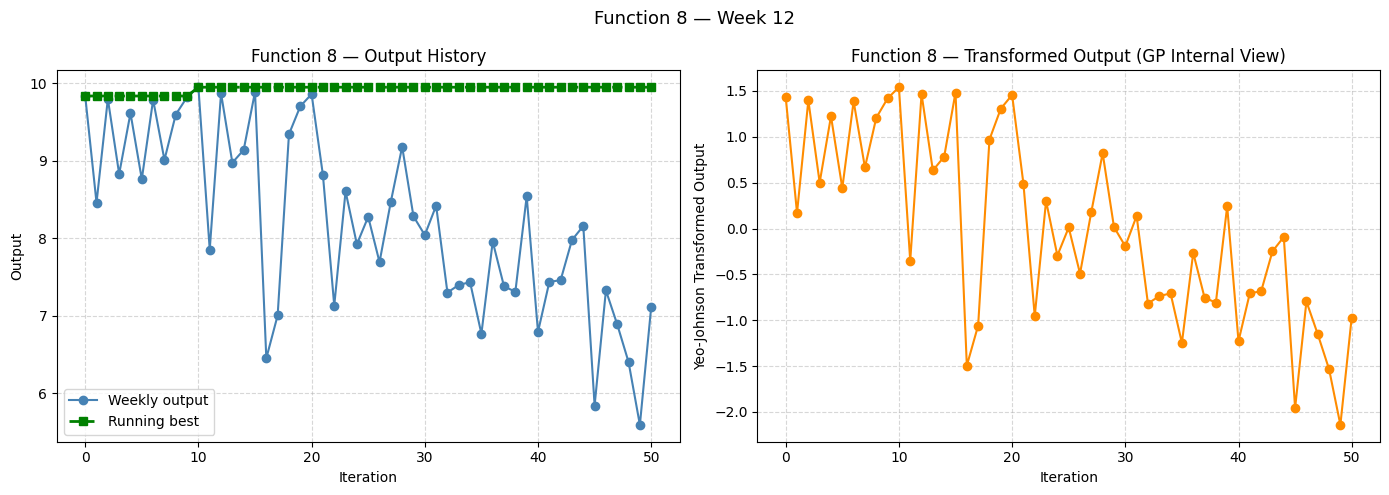

In [7]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(Y_updated, marker='o', color='steelblue', linewidth=1.5, label='Weekly output')
axes[0].plot(running_max, marker='s', color='green', linewidth=2, linestyle='--', label='Running best')
axes[0].set_title('Function 8 — Output History')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Output')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(Y_transformed, marker='o', color='darkorange', linewidth=1.5)
axes[1].set_title('Function 8 — Transformed Output (GP Internal View)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Yeo-Johnson Transformed Output')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Function 8 — Week 12', fontsize=13)
plt.tight_layout()
plt.show()